Final results plots

In [1]:

using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering
using LaTeXStrings


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end


function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=1.0,
    double_ytick_labels::Bool=false
)

    sigma_90 = quantile(Chisq(2), 0.90)

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    
    # Ensure we have enough colors for all results
    if length(colors) < length(results)
        # Extend with default colors if needed
        default_colors = [RGB(0.0, 0.0, 0.0), RGB(0.8, 0.2, 0.2), RGB(0.2, 0.6, 0.2)]
        while length(colors) < length(results)
            push!(colors, default_colors[mod(length(colors), length(default_colors)) + 1])
        end
    end
    colors = colors[1:length(results)]

    if experiments !== nothing
       
        idx_dayabay = findfirst(==("Daya Bay"), experiments)
        if idx_dayabay !== nothing
            colors[idx_dayabay] = cs.colors[3]
        end
        
      
        idx_legend1000 = findfirst(==("LEGEND1000"), experiments)
        if idx_legend1000 !== nothing
            colors[idx_legend1000] = RGB(0.0, 0.2, 0.6)
        end
        
       
        idx_gerda = findfirst(==("GERDA"), experiments)
        if idx_gerda !== nothing
            colors[idx_gerda] = cs.colors[4]
        end
        
       
        idx_junotao = findfirst(==("JUNO+TAO"), experiments)
        if idx_junotao !== nothing
            colors[idx_junotao] = cs.colors[2]
        end
        
       
        idx_legend200 = findfirst(==("LEGEND200"), experiments)
        if idx_legend200 !== nothing
            colors[idx_legend200] = cs.colors[5]
        end
    end

    fig = Figure(size=(8.6*72, 6.5*72))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = false,
        yminorgridvisible = false,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18
    )
    colsize!(fig.layout, 1, Relative(0.95))

    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label = experiments === nothing ? "" : experiments[i]

        is_dashed = label in ["JUNO+TAO", "LEGEND200", "LEGEND1000", "Combined Data + Projections"]
     
        if label == "Daya Bay" || label == "GERDA" || label == "Combined Data"
            is_dashed = false
        end

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        linecolor = if label == "Combined Data" || label == "Combined Data + Projections"
            :black
        else
            colors[i]
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,
            linewidth=2.5,
            linestyle=is_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

function superscript(n)
    superscripts = ['⁰','¹','²','³','⁴','⁵','⁶','⁷','⁸','⁹']
    return join([superscripts[parse(Int, string(d)) + 1] for d in string(n)])
end

function format_scientific_superscript(x)
    if x >= 1
        exp = floor(Int, log10(x))
        mantissa = x / 10^exp
        if mantissa == floor(mantissa)
            return "10$(superscript(exp))"
        else
            return "10$(superscript(exp))"
        end
    end
end

actual_ticks = [2.0, 5.0, 50.0, 500.0, 5000.0]
double_labels = [format_scientific_superscript(val * 2) for val in actual_ticks]
ax.yticks = (actual_ticks, double_labels)

    hlines!(ax, [4999.0], color=cs.colors[1], linewidth=6.0)
    text!(
        ax, 
        ax.finallimits[].widths[1],
        4200.0,
        text="Benchmark",
        align=(:right, :top),
        offset=(-5, 0),
        fontsize=16,
        color=cs.colors[1]
    )

    if experiments !== nothing
        
        legend_elements = []
        legend_labels = []
        
        # Current Data section
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Current Data:")
        
        push!(legend_elements, LineElement(color=colors[findfirst(==("Daya Bay"), experiments)], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "Daya Bay")
        
        push!(legend_elements, LineElement(color=colors[findfirst(==("GERDA"), experiments)], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "GERDA")
        
        push!(legend_elements, LineElement(color=:black, linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "Combined Data")
        
        # Projections section
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Projections:")
        
        push!(legend_elements, LineElement(color=colors[findfirst(==("JUNO+TAO"), experiments)], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "JUNO+TAO")
        
        push!(legend_elements, LineElement(color=colors[findfirst(==("LEGEND200"), experiments)], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "LEGEND200")
        
        push!(legend_elements, LineElement(color=colors[findfirst(==("LEGEND1000"), experiments)], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "LEGEND1000")
        
        push!(legend_elements, LineElement(color=:black, linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "Combined Data + Projections")
        
        # Add legend
        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            backgroundcolor=(:white, 0.5),
            tellwidth=false,
            tellheight=false,
            halign=:right,
            valign=:bottom,
            labelsize=18,
            margin=(10, 10, 20, 10)
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning:

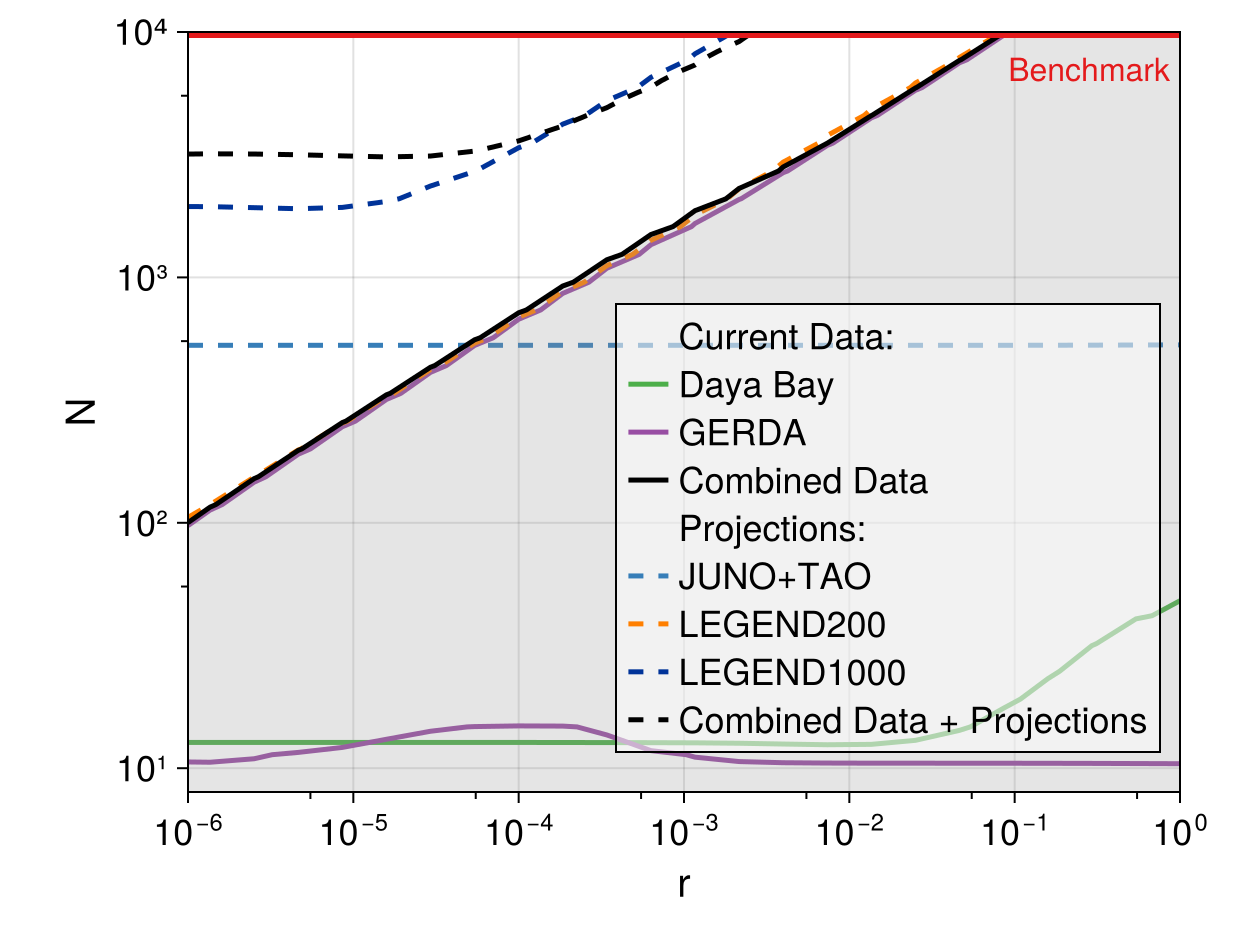

CairoMakie.Screen{IMAGE}


In [2]:
# NNM NO

file_paths = [
"./scan/dayabay_5000_rN_NNM_NO_log_m0=0.01.jld2",
"./scan/junotao_full6_rN_NNM_NO_prof_log9.jld2",
"./scan/gerda5000_rN_NNM_NO_log_m0=0.01.jld2",
"./scan/legend200_5000_rN_NNM_NO_log_m0=0.01.jld2",
"./scan/legend1000_5000_rN_NNM_NO_log_m0=0.01.jld2",
"./scan/global_data_5000_rN_NNM_NO_log_m0=0.01.jld2",
"./scan/global_all_5000_rN_NNM_NO_prof_log_m0=0.01.jld2"
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10, 
    xlims = (1e-6, 1e0),
    ylims = (4,5000.0),
   title="Majorana NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO+TAO","GERDA","LEGEND200","LEGEND1000","Combined Data", "Combined Data + Projections"],
   smooth_sigma=0.8,
   double_ytick_labels=true
  
)

display(fig)

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning:

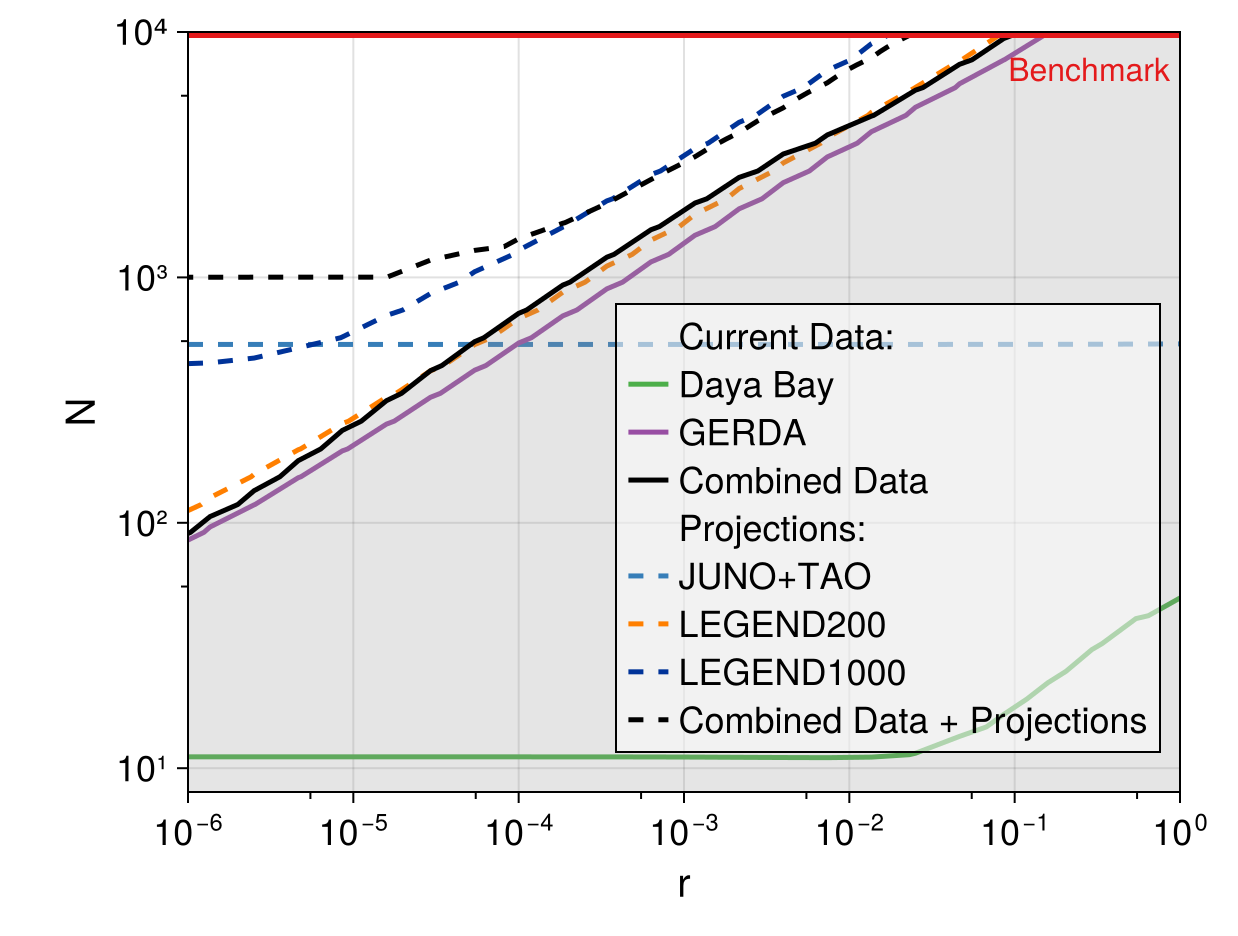

CairoMakie.Screen{IMAGE}


In [3]:
#NNM IO

file_paths = [
"./scan/dayabay_5000_rN_NNM_IO_log_m0=0.01.jld2",
"./scan/junotao_full6_rN_NNM_IO_prof_log9.jld2",
"./scan/gerda5000_rN_NNM_IO_log_m0=0.01.jld2",
"./scan/legend200_5000_rN_NNM_IO_log_m0=0.01.jld2",
"./scan/legend1000_5000_rN_NNM_IO_log_m0=0.01.jld2",
"./scan/global_data_5000_rN_NNM_IO_log_m0=0.01.jld2",
"./scan/global_all_5000_rN_NNM_IO_prof_log_m0=0.01.jld2",
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10,
    xlims = (1e-6, 1e0),
    ylims = (4,5000.0),
   title="Majorana IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO+TAO","GERDA","LEGEND200","LEGEND1000","Combined Data", "Combined Data + Projections"],
   smooth_sigma=0.8,
   double_ytick_labels=true
)

display(fig)

In [4]:
using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering
using ImageFiltering.Kernel

function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=0.2
)

    sigma_90 = quantile(Chisq(2), 0.90)

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[2:length(results)+1]

    fig = Figure(size=(8.6*72, 6.5*72))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = false,
        yminorgridvisible = false,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18
    )
    colsize!(fig.layout, 1, Relative(0.95))
    
   
    daya_bay_indices = []
    for (i, result) in enumerate(results)
        label = experiments === nothing ? "" : experiments[i]
        if occursin("Daya Bay", label)
            push!(daya_bay_indices, i)
        end
    end
    
    for db_idx in daya_bay_indices
        db_result = results[db_idx]
        
        lp = db_result.values.log_posterior
        finite_mask = isfinite.(lp)
        
        if any(finite_mask)
            lp_max = maximum(lp[finite_mask])
            dLLH_raw = 2 .* (lp_max .- lp)
            
            dLLH = smooth_sigma === nothing ?
                dLLH_raw :
                imfilter(dLLH_raw, Kernel.gaussian(smooth_sigma))
            
            dLLH_plot = copy(dLLH)
            dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN
            
            maxlevel = maximum(skipmissing(vec(dLLH_plot)))
            ϵ = 1e-6
            
           
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    db_result.axes[1],
                    db_result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.3),
                                      RGBA(0.6,0.6,0.6,0.3)])
                )
            end
        end
    end
    
   
    for (i,result) in enumerate(results)
        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])
        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(dLLH_raw, Kernel.gaussian(smooth_sigma))

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label = experiments === nothing ? "" : experiments[i]

       
        force_dashed = occursin("JUNO+TAO", label)
     
        linecolor = if occursin("Combined", label)
            :black
        else
            colors[i]
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,
            linewidth=2.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

function superscript(n)
    superscripts = ['⁰','¹','²','³','⁴','⁵','⁶','⁷','⁸','⁹']
    return join([superscripts[parse(Int, string(d)) + 1] for d in string(n)])
end

function format_scientific_superscript(x)
    if x >= 1
        exp = floor(Int, log10(x))
        mantissa = x / 10^exp
        if mantissa == floor(mantissa)
            return "10$(superscript(exp))"
        else
            return "10$(superscript(exp))"
        end
   
    end
end

actual_ticks = [2.0, 5.0, 50.0, 500.0, 5000.0]
double_labels = [format_scientific_superscript(val * 2) for val in actual_ticks]
ax.yticks = (actual_ticks, double_labels)

    hlines!(ax, [4999.0], color=cs.colors[1]  , linewidth=6.0)
    text!(
        ax, 
        ax.finallimits[].widths[1],  
       4200.0,
        text="Benchmark",
        align=(:right, :top),
        offset=(-5, 0),
        fontsize=16,
        color=cs.colors[1]
    )

    if experiments !== nothing
        legend_elements = []
        legend_labels = []
        
      
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Daya Bay:")
        
        push!(legend_elements, LineElement(color=colors[1], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "NO")
        
        push!(legend_elements, LineElement(color=colors[2], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "IO")
      
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "JUNO+TAO:")
        
        push!(legend_elements, LineElement(color=colors[3], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "NO")
        
        push!(legend_elements, LineElement(color=colors[4], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "IO")
        
        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            tellwidth=false,
            tellheight=false,
            halign=:left,
            valign=:bottom,
            labelsize=18,
            framevisible=true,
            backgroundcolor=(:white, 0.5),
            strokecolor=:black,
            strokewidth=0.5,
            margin=(10, 10, 12, 10)
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


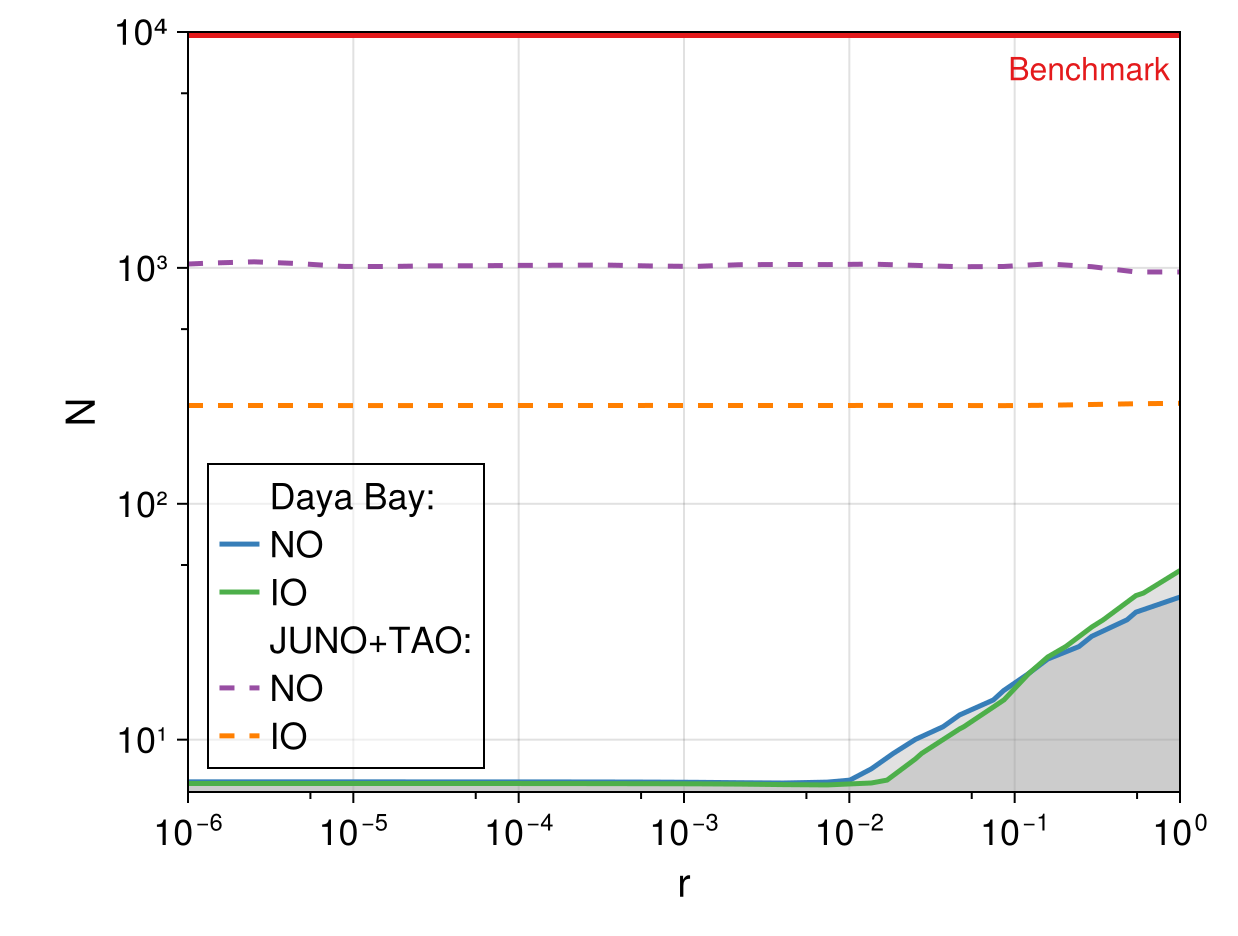

CairoMakie.Screen{IMAGE}


In [5]:
# dirac NO and IO togeher
file_paths = [
"./scan/dayabay_5000_rN_NND_NO_log_m0=0.01.jld2",
"./scan/dayabay_5000_rN_NND_IO_log_m0=0.01.jld2",
"./scan/junotao_full6_rN_NND_NO_prof_log9.jld2",
"./scan/junotao_full6_rN_NND_IO_prof_log9.jld2"]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10,
     xlims = (1e-6, 1e0),
     ylims=(3, 5000),
     title="Dirac NO-IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay NO", "Daya Bay IO", "JUNO+TAO NO", "JUNO+TAO IO"],
   smooth_sigma=0.8

  
)

display(fig)


┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning:

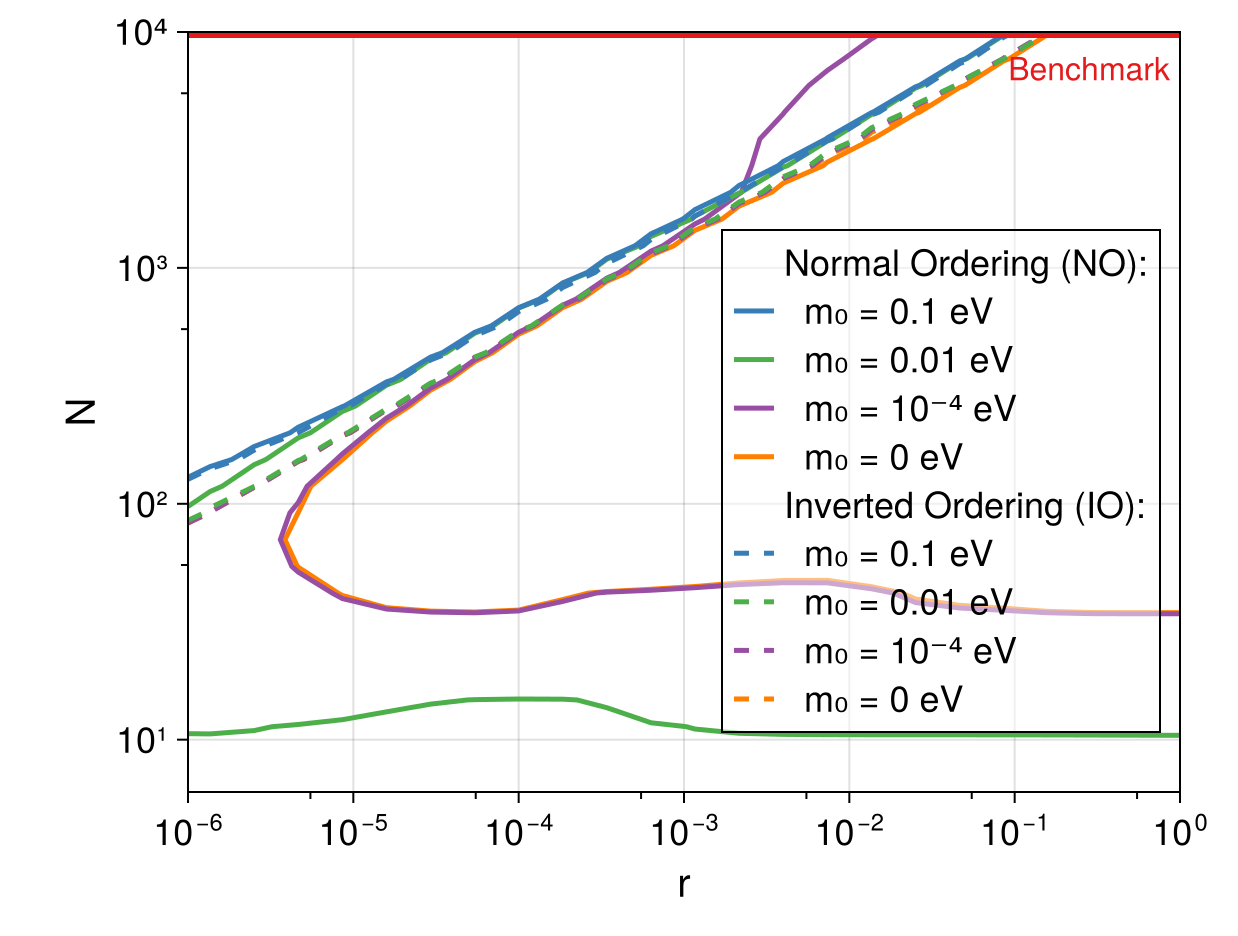

CairoMakie.Screen{IMAGE}


In [6]:
# m0 effect


function superpose_contours_singlepanel(
    file_groups::Vector{Vector{String}};
    title = "",
    m0_labels = ["0 eV", "10⁻⁴ eV", "0.01 eV", "0.1 eV"],
    experiments = nothing,
    colorscheme = nothing,
    color_step = 1,
    xscale = identity,
    yscale = identity,
    xlims = nothing,
    ylims = nothing,
    smooth_sigma::Union{Nothing,Float64} = nothing,
)

   
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end

    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors

    sigma_90_excluded_level = quantile(Chisq(2), 0.90)

  
    fig = Figure(size=(8.6*72, 6.5*72))  
    all_results = []
    all_axes_1 = []
    all_axes_2 = []
    all_m0_indices = []
    all_neutrino_types = []

    for (m0_idx, file_paths) in enumerate(file_groups)
        for file_path in file_paths
            data = load(file_path)
            result = only(values(data))
            
            push!(all_results, result)
            push!(all_axes_1, result.axes[1])
            push!(all_axes_2, result.axes[2])
            push!(all_m0_indices, m0_idx)
            
            # Determine neutrino type from filename
            if contains(file_path, "NO")
                push!(all_neutrino_types, "NO")
            elseif contains(file_path, "IO")
                push!(all_neutrino_types, "IO")
            else
                push!(all_neutrino_types, "unknown")
            end
        end
    end

   
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])

  
    first_result = all_results[1]
    axis_labels = collect(keys(first_result.axes))

    
    ax = Axis(fig[1, 1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true,
        yminorticksvisible = true,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
    colsize!(fig.layout, 1, Relative(0.95))  
    
    if xlims !== nothing
        if ylims !== nothing
            limits!(ax, xlims[1], xlims[2], ylims[1], ylims[2])
        else
            limits!(ax, xlims[1], xlims[2], y_min, y_max)
        end
    elseif ylims !== nothing
        limits!(ax, x_min, x_max, ylims[1], ylims[2])
    else
        limits!(ax, x_min, x_max, y_min, y_max)
    end

function superscript(n)
    superscripts = ['⁰','¹','²','³','⁴','⁵','⁶','⁷','⁸','⁹']
    return join([superscripts[parse(Int, string(d)) + 1] for d in string(n)])
end

function format_scientific_superscript(x)
    if x >= 1
        exp = floor(Int, log10(x))
        mantissa = x / 10^exp
        if mantissa == floor(mantissa)
            return "10$(superscript(exp))"
        else
            return "10$(superscript(exp))"
        end
    end
end

actual_ticks = [2.0, 5.0, 50.0, 500.0, 5000.0]
double_labels = [format_scientific_superscript(val * 2) for val in actual_ticks]
ax.yticks = (actual_ticks, double_labels)

   
    n_m0_values = length(file_groups)
    colors = all_colors[2:color_step:n_m0_values+1]
    
    if n_m0_values > length(colors)
        colors = [colors[i] for i in round.(Int, range(1, length(colors), length=n_m0_values))]
    else
        colors = colors[1:n_m0_values]
    end

    colors = reverse(colors)

    for (idx, result) in enumerate(all_results)
        m0_idx = all_m0_indices[idx]
        neutrino_type = all_neutrino_types[idx]
        
        dLLH_raw = 2 .* (
            maximum(result.values.log_posterior)
            .- result.values.log_posterior
        )

        dLLH = smooth_sigma === nothing ?
            dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        
        color = colors[m0_idx]
       
        linestyle = neutrino_type == "NO" ? :solid : :dash
        
        color_transparent = RGBA(color, 0.8)
        color_transparent_full = RGBA(color, 0.1)

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
    end

    hlines!(ax, [4999.0], color=cs.colors[1]  , linewidth=6.0)
    text!(
        ax, 
        ax.finallimits[].widths[1],  # right edge of x-axis
       4200.0,
        text="Benchmark",
        align=(:right, :top),
        offset=(-5, 0),
        fontsize=16,
        color=cs.colors[1]
    )

    legend_elements = LineElement[]
    legend_labels = String[]
    
    push!(legend_elements, LineElement(color=:transparent, linewidth=0))
    push!(legend_labels, "Normal Ordering (NO):")
    
    for m0_idx in length(file_groups):-1:1  
        push!(legend_elements, LineElement(
            color = colors[m0_idx],
            linewidth = 2.5,
            linestyle = :solid
        ))
        push!(legend_labels, "  m₀ = $(m0_labels[m0_idx])")
    end
    
   
    push!(legend_elements, LineElement(color=:transparent, linewidth=0))
    push!(legend_labels, "Inverted Ordering (IO):")
    
    for m0_idx in length(file_groups):-1:1  
        push!(legend_elements, LineElement(
            color = colors[m0_idx],
            linewidth = 2.5,
            linestyle = :dash
        ))
        push!(legend_labels, "  m₀ = $(m0_labels[m0_idx])")
    end
   
    Legend(
        fig[1,1],
        legend_elements,
        legend_labels;
        tellwidth = false,
        tellheight = false,
        halign = :right,
        valign = :bottom,
        labelsize = 18,
        framevisible = true,
        backgroundcolor = (:white, 0.5),
        strokecolor = :black,
        strokewidth = 0.5,
        margin = (10, 10, 30, 10)
    )

    return fig
end

group1 = [
    "./scan/scan_gerda_rN_m0=0.0_NNM_NO_5000_log.jld2",
    "./scan/scan_gerda_rN_m0=0.0_NNM_IO_5000_log.jld2"
]

group2 = [
    "./scan/scan_gerda_rN_m0=0.0001_NNM_NO_5000_log.jld2",
    "./scan/scan_gerda_rN_m0=0.0001_NNM_IO_5000_log.jld2"
]

group3 = [
    "./scan/scan_gerda_rN_m0=0.01_NNM_NO_5000_log.jld2",
    "./scan/scan_gerda_rN_m0=0.01_NNM_IO_5000_log.jld2"
]

group4 = [
    "./scan/scan_gerda_rN_m0=0.1_NNM_NO_5000_log.jld2",
    "./scan/scan_gerda_rN_m0=0.1_NNM_IO_5000_log.jld2"
]

fig = superpose_contours_singlepanel(
    [group1, group2, group3, group4];
    title = "",
    m0_labels = ["0 eV", "10⁻⁴ eV", "0.01 eV", "0.1 eV"],
    colorscheme = :Set1_9,
    xscale = log10,
    yscale = log10,
    xlims = (1e-6, 1e0),
    ylims=(3, 5000),
    smooth_sigma = 0.8,
    color_step = 1
)

display(fig)


GERDA plots

In [7]:
# NNATURALNESS

using Revise
using Newtrinos

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);

par= Newtrinos.get_params(experiments)


[ Info: Loading Gerda data


(N = 20.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.05, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

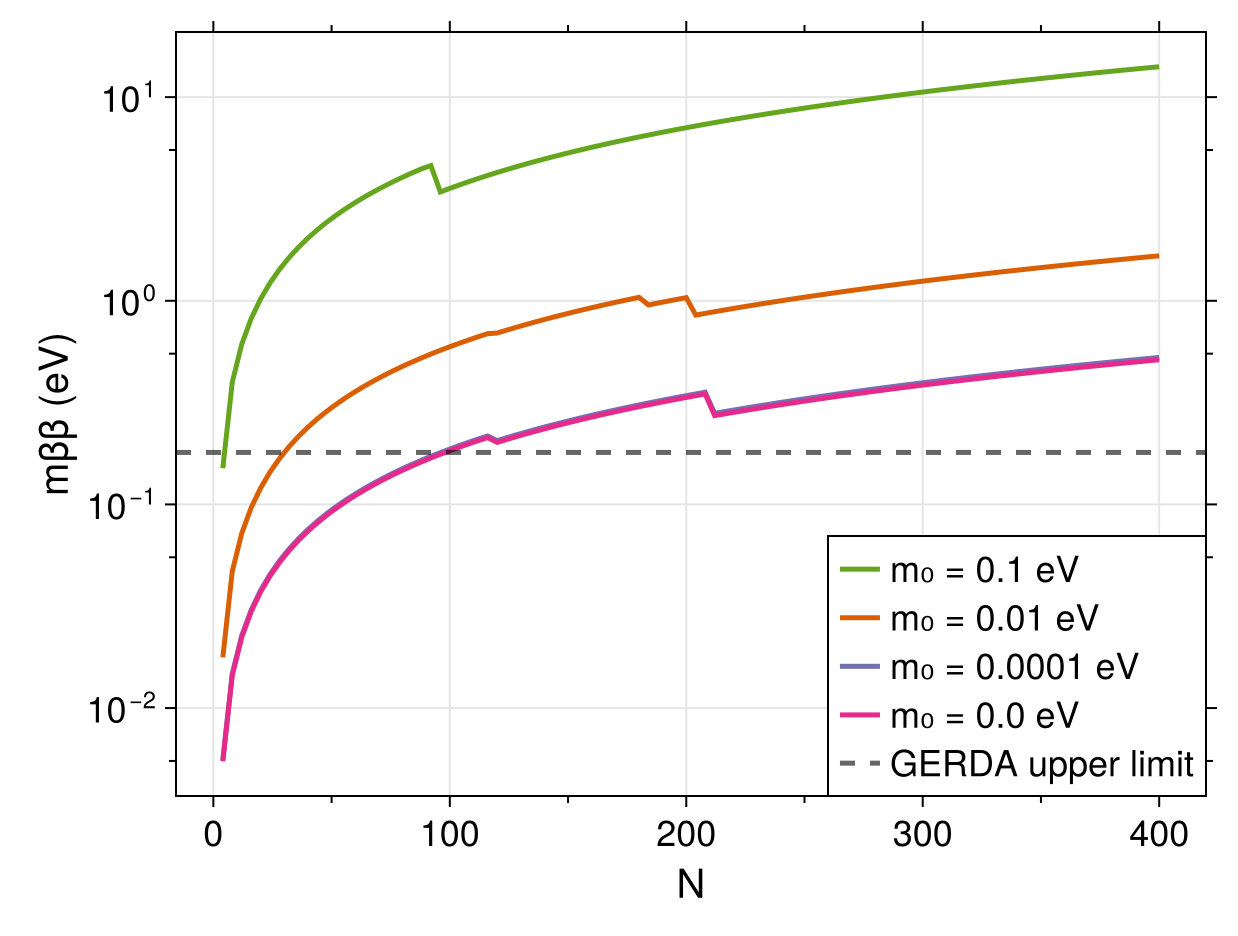

CairoMakie.Screen{IMAGE}


In [8]:
using CairoMakie
using ColorSchemes

# ===================== PARAMETERS =====================

N_range = range(4, 400, length = 100)
m0_values = [0.1, 0.01,  0.0001, 0.0]

mass_by_m0 = Dict(m0 => Float64[] for m0 in m0_values)

f = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)

# ===================== COMPUTATION =====================

for n in N_range
    for m0 in m0_values
        p = merge(par, (m₀ = m0,), (r = 1,), (N = n/2,))
        push!(mass_by_m0[m0], f(p))
    end
end

# ===================== COLORS =====================

cs = ColorSchemes.Dark2_8

c_m01    = cs[5]  # m0 = 0.1
c_m001   = cs[2]  # m0 = 0.01
c_m0001  = cs[3]  # m0 = 0.001
c_m00001 = cs[4]  # m0 = 0.0001

colors = Dict(
    0.1    => c_m01,
    0.01   => c_m001,
    0.0001  => c_m0001,
    0.0    => c_m00001
)

# ===================== FIGURE =====================

fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")
 # PRD single column width

ax = Axis(
    fig[1, 1],
    xlabel = "N",
    ylabel = "mββ (eV)",
    yscale = log10,
    xminorticksvisible = true,
    yminorticksvisible = true,
    titlesize = 18,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

# ===================== PLOTS =====================

for m0 in m0_values
    lines!(
        ax,
        N_range,
        mass_by_m0[m0];
        color = colors[m0],
        linewidth = 2.5,
        label = "m₀ = $(m0) eV"
    )
end

# ===================== GERDA LIMIT =====================

hlines!(
    ax,
    0.18;
    linestyle = :dash,
    linewidth = 2.5,
    color = (:black, 0.6),
    label = "GERDA upper limit"
)

# ===================== LEGEND WITH BOX =====================

# Create legend elements
legend_elements = []
legend_labels = []

for m0 in m0_values
    push!(legend_elements, LineElement(color = colors[m0], linewidth = 2.5, linestyle = :solid))
    push!(legend_labels, "m₀ = $(m0) eV")
end

push!(legend_elements, LineElement(color = (:black, 0.6), linewidth = 2.5, linestyle = :dash))
push!(legend_labels, "GERDA upper limit")

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 18,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "m₀ values",
    titlefont = :bold,
    titlesize = 20
)


display(fig)


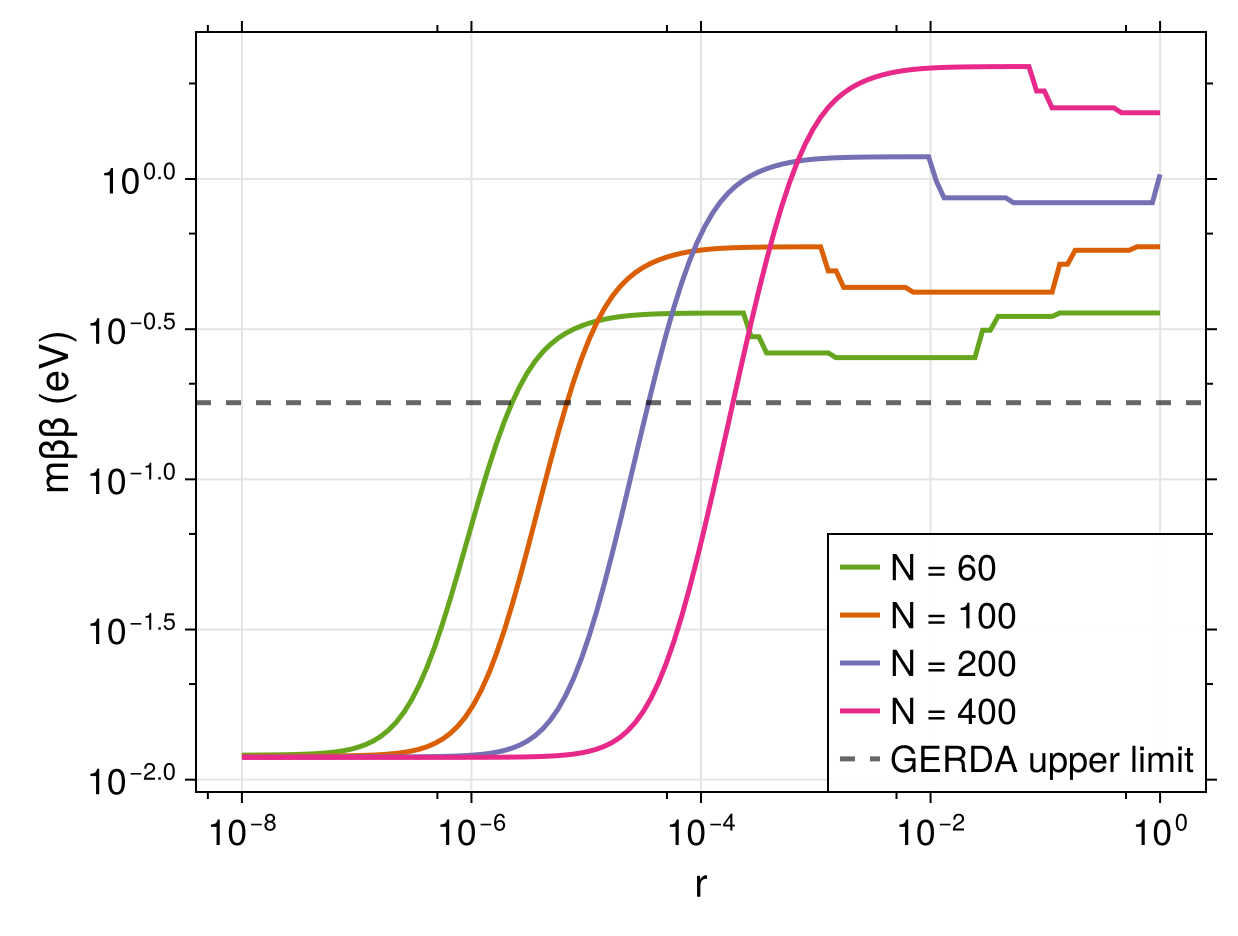

CairoMakie.Screen{IMAGE}


In [9]:
using CairoMakie
using ColorSchemes

# ===================== PARAMETERS =====================

r_range = logrange(1e-8, 1.0, 120)
N_values = [30, 50, 100, 200]
m0 = 0.01

mass_by_N = Dict(N => Float64[] for N in N_values)

f = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)

# ===================== COMPUTATION =====================

for r in r_range
    for N in N_values
        p = merge(par, (m₀ = m0,), (r = r,), (N = N,))
        push!(mass_by_N[N], f(p))
    end
end

# ===================== COLORS (ORIGINAL ASSIGNMENTS PRESERVED) =====================

cs = ColorSchemes.Dark2_8

c_N30  = cs[5]   
c_N50  = cs[2]   
c_N100 = cs[3]   
c_N200 = cs[4]   

colors = Dict(
    30  => c_N30,
    50  => c_N50,
    100 => c_N100,
    200 => c_N200
)

# ===================== FIGURE =====================

fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")  

ax = Axis(
    fig[1, 1],
    xlabel = "r",
    ylabel = "mββ (eV)",
    xscale = log10,
    yscale = log10,
    xminorticksvisible = true,
    yminorticksvisible = true,
    titlesize = 18,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

# ===================== PLOTS =====================

for N in N_values
    Nn=2*N  
    lines!(
        ax,
        r_range,
        mass_by_N[N];
        color = colors[N],
        linewidth = 2.5,
        label = "N = $Nn"
    )
end

# ===================== GERDA LIMIT =====================

hlines!(
    ax,
    0.18;
    linestyle = :dash,
    linewidth = 2.5,
    color = (:black, 0.6),
    label = "GERDA upper limit"
)

# ===================== LEGEND WITH BOX =====================

# Create legend elements
legend_elements = []
legend_labels = []

for N in N_values
      Nn=2*N  
    push!(legend_elements, LineElement(color = colors[N], linewidth = 2.5, linestyle = :solid))
    push!(legend_labels, "N = $Nn")
end

push!(legend_elements, LineElement(color = (:black, 0.6), linewidth = 2.5, linestyle = :dash))
push!(legend_labels, "GERDA upper limit")

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 18,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "N values",
    titlefont = :bold,
    titlesize = 20
)


display(fig)


Oscillations plots

In [10]:

using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using Revise
using Newtrinos
using CairoMakie
using ColorSchemes
using DataFrames

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

  dayabay= Newtrinos.dayabay.configure(physics),
);

p = Newtrinos.get_params(experiments)

[ Info: Loading dayabay data


(N = 20.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.05, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [11]:

# STANDARD MODEL

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers)

experiments_SM = (
    dayabay = Newtrinos.dayabay.configure(physics_SM),
)

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)


# N-NATURALNESS

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc)

experiments = (
    dayabay = Newtrinos.dayabay.configure(physics),
)

p = Newtrinos.get_params(experiments)


p_5  = merge(p, (N=5.0,  r=1.0))
p_10 = merge(p, (N=10.0, r=1.0))
p_20 = merge(p, (N=20.0, r=1.0))
p_50 = merge(p, (N=50.0, r=1.0))


[ Info: Loading dayabay data
[ Info: Loading dayabay data


(N = 50.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.05, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

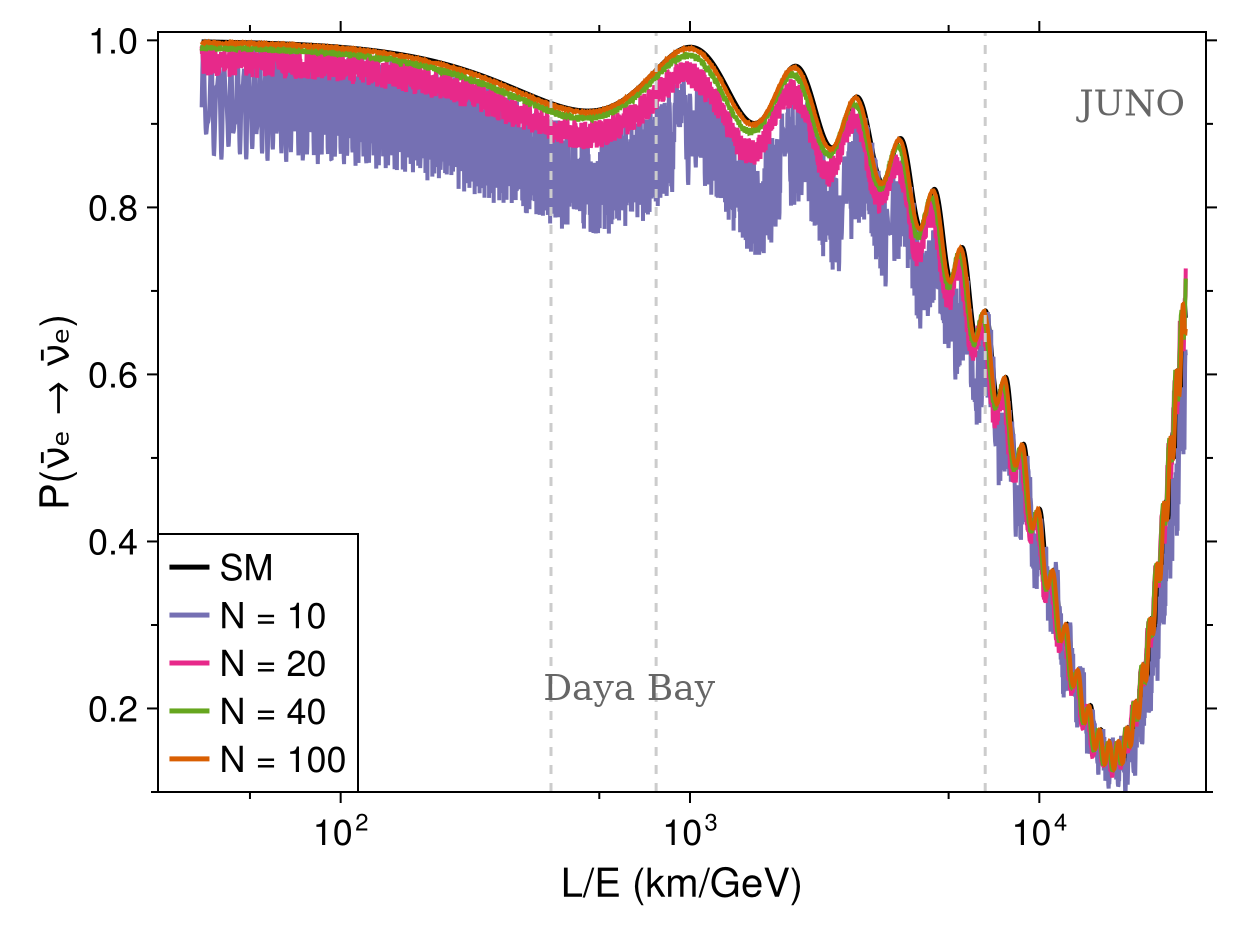

CairoMakie.Screen{IMAGE}


In [12]:

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p = Newtrinos.get_params(experiments)

LE_min = 1.6 / 0.04      
LE_max = 52.5 / 0.002   

LE_range = exp10.(range(log10(LE_min),
                        log10(LE_max),
                        length=3000))

L_ref = 52.5 

E_vals = collect(L_ref ./ LE_range)

L_vec = [L_ref]


# PROBABILITIES

probab_SM = osc_prob_SM(E_vals, L_vec, p_SM; anti=true)

probab_5  = osc_prob(E_vals, L_vec, p_5; anti=true)
probab_10 = osc_prob(E_vals, L_vec, p_10; anti=true)
probab_20 = osc_prob(E_vals, L_vec, p_20; anti=true)
probab_50 = osc_prob(E_vals, L_vec, p_50; anti=true)


# PLOT

palette = cgrad(:Dark2_8, categorical=true)
c_1 = palette[1]  
c_2 = palette[2]  
c_3 = palette[3]  
c_4 = palette[4] 
c_5 = palette[5]


fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")

ax = Axis(
    fig[1,1],
    xlabel = "L/E (km/GeV)", 
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    xlabelsize = 20,
    ylabelsize = 20,
    titlesize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
    xgridvisible = false,
    ygridvisible = false,
    xticksmirrored = true,
    yticksmirrored = true,
    xminorticksvisible = true,
    yminorticksvisible = true,
    xscale = log10
)

lines!(ax, LE_range, probab_SM[:,1,1,1],
    label = "SM", linewidth = 2, color = :black) 

lines!(ax, LE_range, probab_5[:,1,1,1],
    label = "N = 10", linewidth = 2, color = c_3)

lines!(ax, LE_range, probab_10[:,1,1,1],
    label = "N = 20", linewidth = 2, color = c_4)

lines!(ax, LE_range, probab_20[:,1,1,1],
    label = "N = 40", linewidth = 2, color = c_5)

lines!(ax, LE_range, probab_50[:,1,1,1],
    label = "N = 100", linewidth = 2, color = c_2)



ylims!(ax, 0.10, 1.01)
xlims!(ax, 30, 30000)


legend_elements = [
    LineElement(color=:black, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_3, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_4, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_5, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_2, linewidth=2.5, linestyle=:solid)
]

legend_labels = ["SM", "N = 10", "N = 20", "N = 40", "N = 100"]

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :left,
    valign = :bottom,
    labelsize = 18,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "Oscillation Probabilities",
    titlefont = :bold,
    titlesize = 20
)


vlines!(ax, [1.6/0.002], linestyle=:dash, color=:gray80, linewidth=1.5)   
vlines!(ax, [1.6/0.004], linestyle=:dash, color=:gray80, linewidth=1.5)
vlines!(ax, [52.5/0.001], linestyle=:dash, color=:gray80, linewidth=1.5) 
vlines!(ax, [52.5/0.0075], linestyle=:dash, color=:gray80, linewidth=1.5)


text!(ax, 380, 0.2, text = "Daya Bay", fontsize = 18, color = :gray40)
text!(ax, 13000, 0.9, text = "JUNO", fontsize = 18, color = :gray40)


display(fig)


[ Info: Loading dayabay data
[ Info: Loading dayabay data


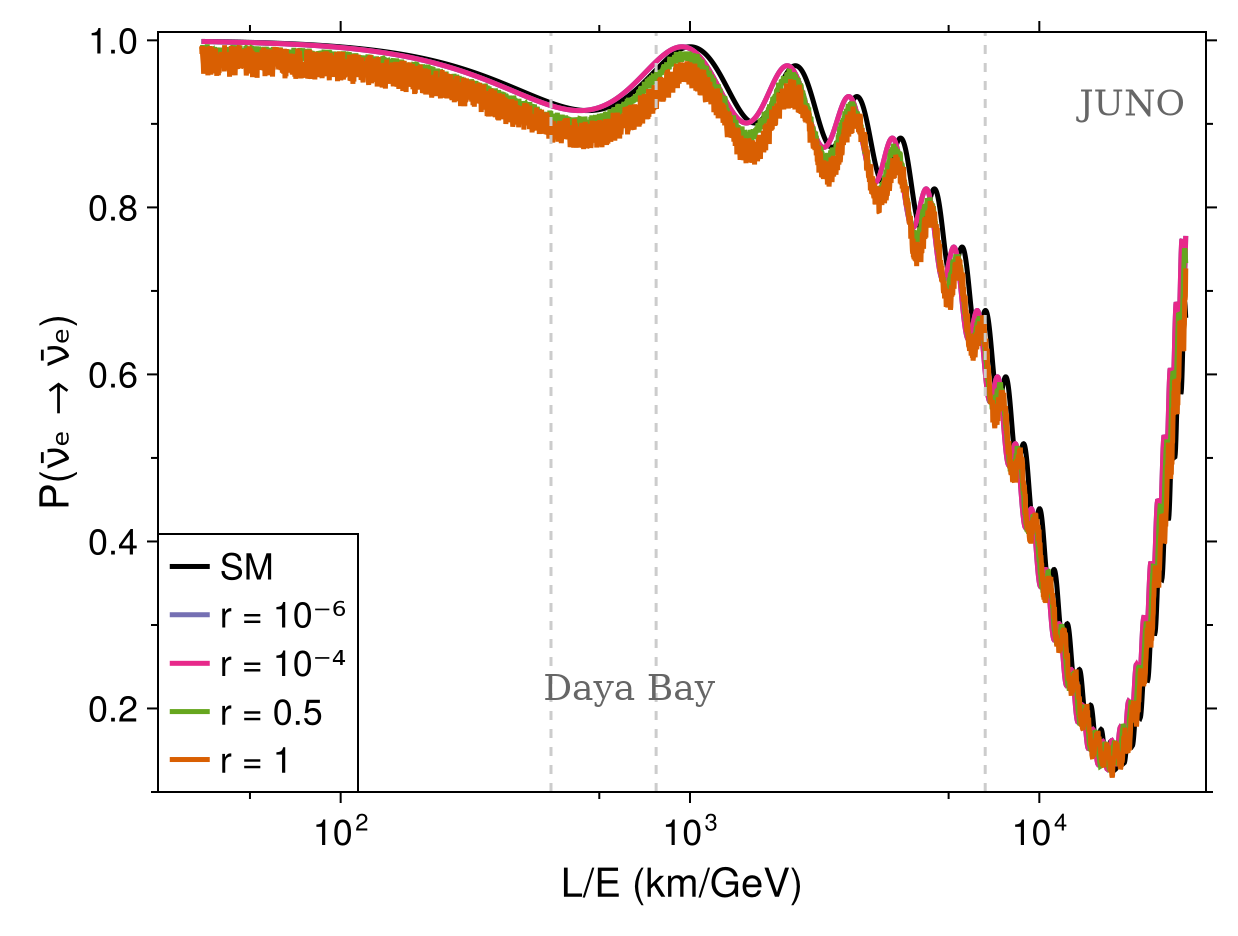

CairoMakie.Screen{IMAGE}


In [13]:

# STANDARD MODEL


osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers)

experiments_SM = (
    dayabay = Newtrinos.dayabay.configure(physics_SM),
)

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc)

experiments = (
    dayabay = Newtrinos.dayabay.configure(physics),
)

osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p = Newtrinos.get_params(experiments)


ftype = typeof(p.N)
p_r0   = merge(p, (N=ftype(10), r=ftype(1e-6)))
p_r025 = merge(p, (N=ftype(10), r=ftype(1e-4)))
p_r05  = merge(p, (N=ftype(11), r=ftype(0.5))) 
p_r1   = merge(p, (N=ftype(10), r=ftype(1)))


LE_min = 1.6 / 0.04      
LE_max = 52.5 / 0.002   

LE_range = exp10.(range(log10(LE_min),
                        log10(LE_max),
                        length=3000))

L_ref = 52.5  

E_vals = collect(L_ref ./ LE_range)

L_vec = [L_ref]

# PROBABILITIES

probab_SM = osc_prob_SM(E_vals, L_vec, p_SM; anti=true)

probab_r0   = osc_prob(E_vals, L_vec, p_r0; anti=true)
probab_r025 = osc_prob(E_vals, L_vec, p_r025; anti=true)
probab_r05  = osc_prob(E_vals, L_vec, p_r05; anti=true)
probab_r1   = osc_prob(E_vals, L_vec, p_r1; anti=true)



palette = cgrad(:Dark2_8, categorical=true)
c_1 = palette[1] 
c_2 = palette[2]
c_3 = palette[3]  
c_4 = palette[4]  
c_5 = palette[5]  

fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif") 

ax = Axis(
    fig[1,1],
    xlabel = "L/E (km/GeV)", 
    ylabel = "P(ν̄ₑ → ν̄ₑ)",  
    xlabelsize = 20,
    ylabelsize = 20,
    titlesize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
    xgridvisible = false,
    ygridvisible = false,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true,
    xminorticksvisible = true,
    yminorticksvisible = true,
    xscale = log10
)

lines!(ax, LE_range, probab_SM[:,1,1,1],
    label = "SM", linewidth = 2.5, color = :black)  

lines!(ax, LE_range, probab_r0[:,1,1,1],
    label = "r = 10⁻⁶", linewidth = 2.5, color = c_3)

lines!(ax, LE_range, probab_r025[:,1,1,1],
    label = "r = 10⁻⁴", linewidth = 2.5, color = c_4)

lines!(ax, LE_range, probab_r05[:,1,1,1],
    label = "r = 0.5", linewidth = 2.5, color = c_5)

lines!(ax, LE_range, probab_r1[:,1,1,1],
    label = "r = 1", linewidth = 2.5, color = c_2)


ylims!(ax, 0.10, 1.01)
xlims!(ax, 30, 30000)

legend_elements = [
    LineElement(color=:black, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_3, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_4, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_5, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_2, linewidth=2.5, linestyle=:solid)
]

legend_labels = ["SM", "r = 10⁻⁶", "r = 10⁻⁴", "r = 0.5", "r = 1"]

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :left,
    valign = :bottom,
    labelsize = 18,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "Oscillation Probabilities",
    titlefont = :bold,
    titlesize = 20
)

vlines!(ax, [1.6/0.002], linestyle=:dash, color=:gray80, linewidth=1.5)   
vlines!(ax, [1.6/0.004], linestyle=:dash, color=:gray80, linewidth=1.5)
vlines!(ax, [52.5/0.001], linestyle=:dash, color=:gray80, linewidth=1.5) 
vlines!(ax, [52.5/0.0075], linestyle=:dash, color=:gray80, linewidth=1.5)


text!(ax, 380, 0.2, text = "Daya Bay", fontsize = 18, color = :gray40)
text!(ax, 13000, 0.9, text = "JUNO", fontsize = 18, color = :gray40)

display(fig)

Daya Bay plots with data

In [14]:
using CairoMakie
using ColorSchemes

    function plot_r(params, data = assets.observed)
        assets=experiments.dayabay.assets
        r_values = [10^-6, 10^-4, 0.5, 1]
        r_labels = ["10⁻⁶", "10⁻⁴", "0.5", "1"] 

        
        palette = cgrad(:Dark2_8, categorical=true)
        
        c_1 = palette[1]  
        c_2 = palette[2]  
        c_3 = palette[3] 
        c_4 = palette[4] 
        c_5 = palette[5]

        colors = [c_3, c_4, c_5, c_2]

      
        all_means = []
        all_variances = []

        forward = Newtrinos.dayabay.get_forward_model(physics, assets)

        for r in r_values
            p_r = merge(params, (r = Float64(r),))
            m = mean(forward(p_r))
            v = var(forward(p_r))

            push!(all_means, m)
            push!(all_variances, v)
        end

      
       fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")  

        ax = Axis(fig[1,1], 
            ylabel = "Counts", 
            xlabelsize = 20,
            ylabelsize = 20,
            titlesize = 20,
            xticklabelsize = 18,
            yticklabelsize = 18,
            xgridvisible = true,
            ygridvisible = true,
            xgridcolor = :gray90,
            ygridcolor = :gray90,
            xticksmirrored = true,
            yticksmirrored = true,
            xminorticksvisible = true,
            yminorticksvisible = true,
            
        )

        ax2 = Axis(
            fig[2,1],
            xlabel = "E (MeV)",
            ylabel = "Data / Predictions",
            xlabelsize = 20,
            ylabelsize = 20,
            titlesize = 20,
            xticklabelsize = 18,
            yticklabelsize = 18,
            xgridvisible = true,
            ygridvisible = true,
            xgridcolor = :gray90,
            ygridcolor = :gray90,
            xticksmirrored = true,
            yticksmirrored = true,
            xminorticksvisible = true,
            yminorticksvisible = true,
            
        )
        
        
        rowsize!(fig.layout, 1, Relative(0.45))  
        rowsize!(fig.layout, 2, Relative(0.55))  
        rowgap!(fig.layout, 5)

        
        for (i, r) in enumerate(r_values)

            m = all_means[i]
            v = all_variances[i]
            col = colors[i]

            stephist!(
                ax,
                assets.energy,
                weights = m,
                bins = assets.energy_bins,
                color = col,
                label = "Expected r = $(r_labels[i])",
                linewidth = 2
            )

            barplot!(
                ax,
                assets.energy,
                m .+ sqrt.(v),
                width = diff(assets.energy_bins),
                gap = 0,
                fillto = m .- sqrt.(v),
                alpha = 0.25,
                color = col
            )

            
            stephist!(
                ax2,
                assets.energy,
                weights = data ./ m,
                bins = assets.energy_bins,
                color = col,
                label = "Ratio r = $(r_labels[i])",
                linewidth = 2
            )
        end
        
        
        last_idx = length(r_values)
        m_last = all_means[last_idx]
        v_last = all_variances[last_idx]
        
        barplot!(
            ax2,
            assets.energy,
            1 .+ sqrt.(v_last) ./ m_last,
            width = diff(assets.energy_bins),
            gap = 0,
            fillto = 1 .- sqrt.(v_last) ./ m_last,
            alpha = 0.25,
            color = :gray
        )
             
        plot!(
            ax,
            assets.energy,
            data,
            color = :black,
            label = "Observed",
    
        )
        hlines!(ax2, 1, color=:black, linestyle=:dash, linewidth=2.5)

        
        ax.xticksvisible = false
        ax.xticklabelsvisible = false

        xlims!(ax, minimum(assets.energy_bins), maximum(assets.energy_bins))
        xlims!(ax2, minimum(assets.energy_bins), maximum(assets.energy_bins))

        ylims!(ax, 0, 60000)
        ylims!(ax2, 0.9, 1.1)

       
        legend_elements = []
        for (i, r) in enumerate(r_values)
            push!(legend_elements, LineElement(color=colors[i], linewidth=2.5, linestyle=:solid))
        end
        push!(legend_elements, MarkerElement(color=:black, marker=:circle, markersize=10))
        
        legend_labels = ["r = $(r_labels[i])" for i in 1:length(r_values)]
        push!(legend_labels, "Observed")
        
        
        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            tellwidth = false,
            tellheight = false,
            halign = :right,
            valign = :top,
            labelsize = 20,
            framevisible = true,
            backgroundcolor = (:white, 0.95),
            strokecolor = :black,
            strokewidth = 0.5,
            title = "N values",
            titlefont = :bold,
            titlesize = 20
        )
        return fig
       
    end



    function plot_N(params, data = assets.observed)
        assets=experiments.dayabay.assets

        N_values = [5, 10, 20, 50]

      
        palette = cgrad(:Dark2_8, categorical=true)
        
        c_1 = palette[1] 
        c_2 = palette[2]  
        c_3 = palette[3] 
        c_4 = palette[4]
        c_5 = palette[5] 

        colors = Dict(
            5 => c_3,
            10 => c_4,
            20 => c_5,
            50 => c_2
        )

        
        all_means = Dict()
        all_variances = Dict()

        forward =Newtrinos.dayabay.get_forward_model(physics, assets)
       
        for N in N_values
            p_N = merge(params, (N = Float64(N),))
            m = mean(forward(p_N))
            v = var(forward(p_N))
            all_means[N] = m
            all_variances[N] = v
        end

        fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif") 

        ax = Axis(fig[1,1], 
            ylabel = "Counts", 
            xlabelsize = 20,
            ylabelsize = 20,
            titlesize = 20,
            xticklabelsize = 18,
            yticklabelsize = 18,
            xgridvisible = true,
            ygridvisible = true,
            xgridcolor = :gray90,
            ygridcolor = :gray90,
            xticksmirrored = true,
            yticksmirrored = true,
            xminorticksvisible = true,
            yminorticksvisible = true,
          
        )

        ax2 = Axis(
            fig[2,1],
            xlabel = "E (MeV)",
            ylabel = "Data / Predictions",
            xlabelsize = 20,
            ylabelsize = 20,
            titlesize = 20,
            xticklabelsize = 18,
            yticklabelsize = 18,
            xgridvisible = true,
            ygridvisible = true,
            xgridcolor = :gray90,
            ygridcolor = :gray90,
            xticksmirrored = true,
            yticksmirrored = true,
            xminorticksvisible = true,
            yminorticksvisible = true,
           
        )
        
       
        rowsize!(fig.layout, 1, Relative(0.45))  
        rowsize!(fig.layout, 2, Relative(0.55))  
        rowgap!(fig.layout, 5)

        for N in sort(N_values)
            m = all_means[N]
            v = all_variances[N]
            col = colors[N]

            stephist!(
                ax,
                assets.energy,
                weights = m,
                bins = assets.energy_bins,
                color = col,
                label = "Expected N = $(N)",
                linewidth = 2
            )

            barplot!(
                ax,
                assets.energy,
                m .+ sqrt.(v),
                width = diff(assets.energy_bins),
                gap = 0,
                fillto = m .- sqrt.(v),
                alpha = 0.25,
                color = col
            )

            # --- ratio ---
            stephist!(
                ax2,
                assets.energy,
                weights = data ./ m,
                bins = assets.energy_bins,
                color = col,
                linewidth = 2
            )
        end
        
        last_N = sort(N_values)[end]
        m_last = all_means[last_N]
        v_last = all_variances[last_N]
        
        barplot!(
            ax2,
            assets.energy,
            1 .+ sqrt.(v_last) ./ m_last,
            width = diff(assets.energy_bins),
            gap = 0,
            fillto = 1 .- sqrt.(v_last) ./ m_last,
            alpha = 0.25,
            color = :gray
        )
             
        plot!(
            ax,
            assets.energy,
            data,
            color = :black,
            label = "Observed"      
              )


        hlines!(ax2, 1, color=:black, linestyle=:dash, linewidth=2)

        
        ax.xticksvisible = false
        ax.xticklabelsvisible = false

        xlims!(ax, minimum(assets.energy_bins), maximum(assets.energy_bins))
        xlims!(ax2, minimum(assets.energy_bins), maximum(assets.energy_bins))

        ylims!(ax, 0, 60000)
        ylims!(ax2, 0.9, 1.2)

        
        legend_elements = []
        for N in sort(N_values)
            push!(legend_elements, LineElement(color=colors[N], linewidth=2.5, linestyle=:solid))
           
        end
        push!(legend_elements, MarkerElement(color=:black, marker=:circle, markersize=10))
        
        legend_labels = ["N = $(N)" for N in sort(N_values.*2)]
        push!(legend_labels, "Observed")
        
        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            tellwidth = false,
            tellheight = false,
            halign = :right,
            valign = :top,
            labelsize = 18,
            framevisible = true,
            backgroundcolor = (:white, 0.95),
            strokecolor = :black,
            strokewidth = 0.5,
            title = "N values",
            titlefont = :bold,
            titlesize = 20
        )
          return fig
     
    end



plot_N (generic function with 2 methods)

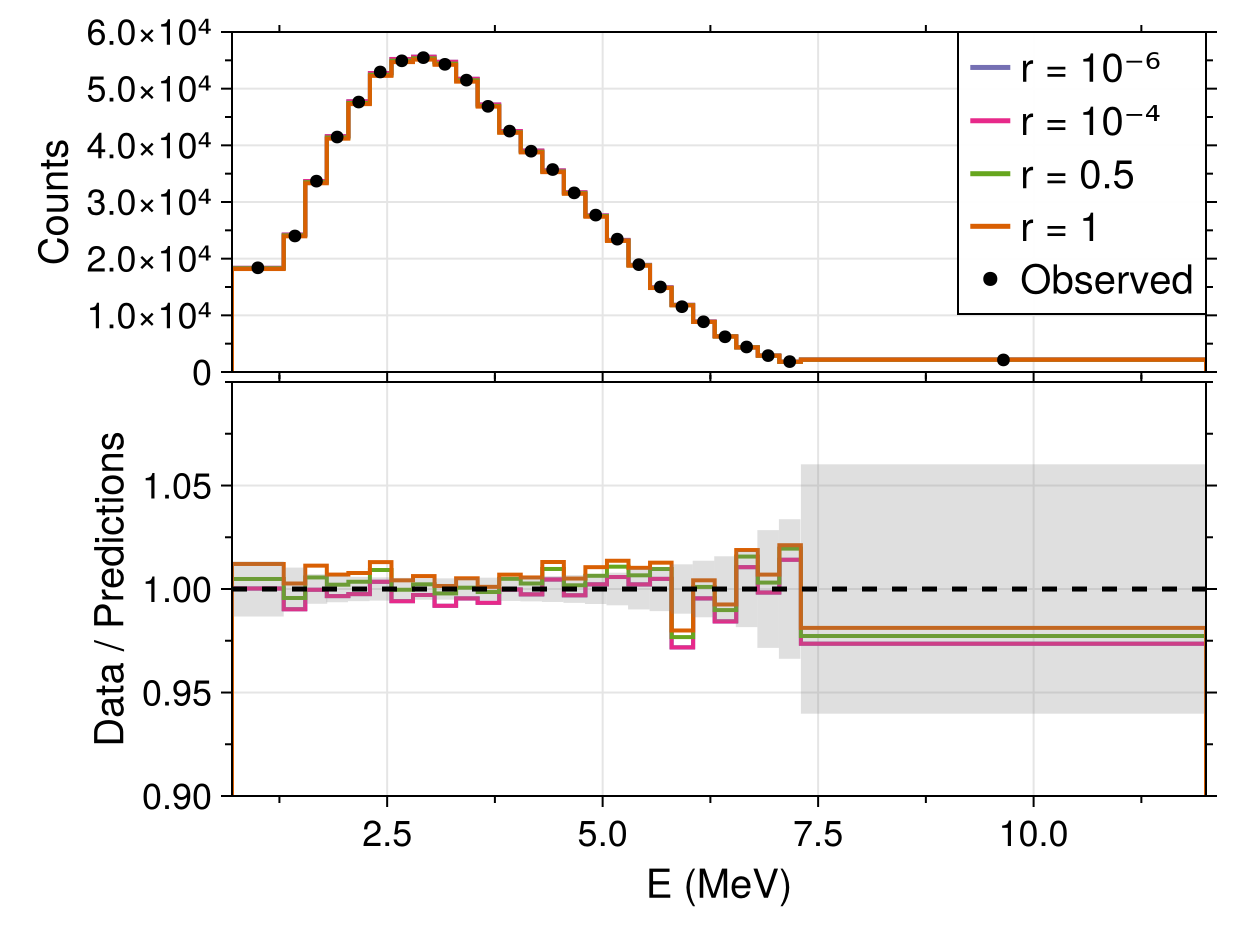

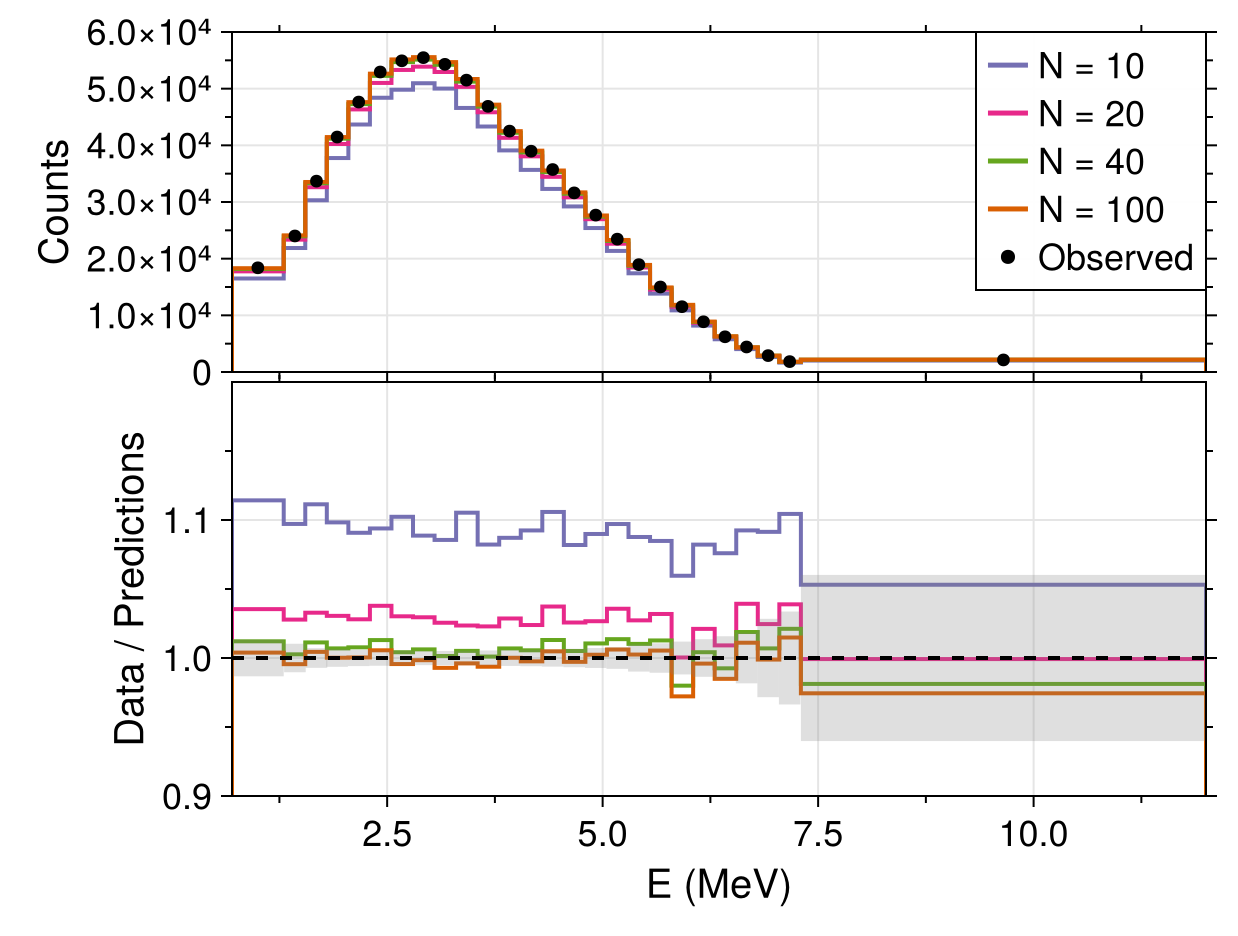

CairoMakie.Screen{IMAGE}


In [15]:
fig_r= plot_r(p, experiments.dayabay.assets.observed)
display(fig_r)

fig_N = plot_N(p, experiments.dayabay.assets.observed)
display(fig_N)
